<a href="https://colab.research.google.com/github/Ethiraj-tech/git-journey/blob/main/California_road_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import gzip
import shutil
import pandas as pd

# URL of the dataset
dataset_url = 'https://snap.stanford.edu/data/roadNet-CA.txt.gz'
local_gz_file = 'roadNet-CA.txt.gz'
local_txt_file = 'roadNet-CA.txt'

print(f"Downloading {dataset_url}...")
response = requests.get(dataset_url, stream=True)
response.raise_for_status() # Raise an exception for bad status codes

with open(local_gz_file, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)
print(f"Download complete. File saved as {local_gz_file}.")

print(f"Decompressing {local_gz_file}...")
with gzip.open(local_gz_file, 'rb') as f_in:
    with open(local_txt_file, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
print(f"Decompression complete. File saved as {local_txt_file}.")

# Load the decompressed file into a pandas DataFrame
# The dataset seems to be a list of edges, typically space or tab-separated.
# Based on common SNAP dataset formats, it's likely two columns with comments starting with '#'
df = pd.read_csv(local_txt_file, sep='\t', comment='#', header=None, names=['source', 'destination'])

print("Dataset loaded successfully into a pandas DataFrame.")


Download complete. File saved as roadNet-CA.txt.gz.
Decompressing roadNet-CA.txt.gz...
Decompression complete. File saved as roadNet-CA.txt.
Dataset loaded successfully into a pandas DataFrame.


In [2]:
# Display the first 5 rows of the DataFrame
display(df.head())

,source,destination
0,0,1
1,0,2
2,0,469
3,1,0
4,1,6


In [3]:
df.describe

<bound method NDFrame.describe of           source  destination
0              0            1
1              0            2
2              0          469
3              1            0
4              1            6
...          ...          ...
5533209  1971240      1971238
5533210  1971250      1971249
5533211  1971269      1971268
5533212  1971277      1971276
5533213  1971278      1971276

[5533214 rows x 2 columns]>

In [5]:
display(df.describe())

,source,destination
count,5.533214e+06,5.533214e+06
mean,9.798579e+05,9.798579e+05
std,5.678222e+05,5.678222e+05
min,0.000000e+00,0.000000e+00
25%,4.898930e+05,4.898930e+05
50%,9.779005e+05,9.779005e+05
75%,1.472587e+06,1.472587e+06
max,1.971280e+06,1.971280e+06


In [6]:
print("Checking for missing values:")
display(df.isnull().sum())

Checking for missing values:


,0
source,0
destination,0


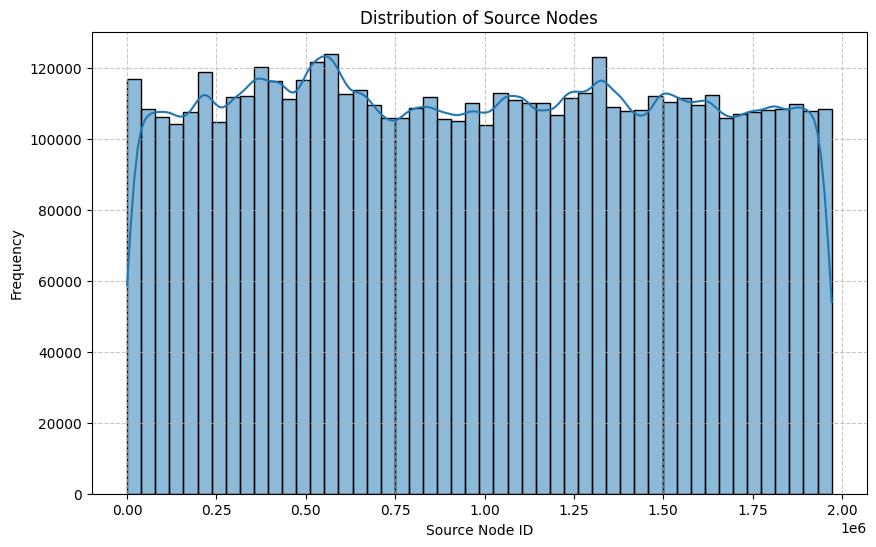

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['source'], bins=50, kde=True)
plt.title('Distribution of Source Nodes')
plt.xlabel('Source Node ID')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

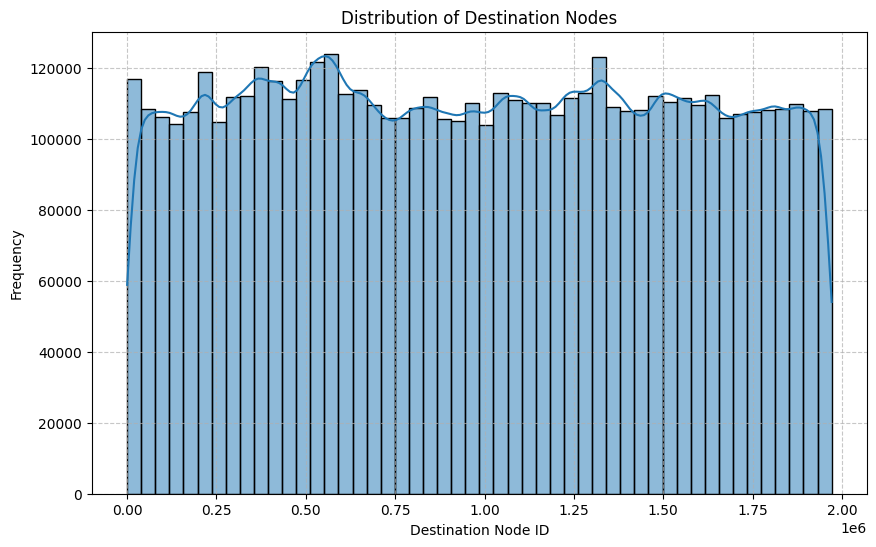

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['destination'], bins=50, kde=True)
plt.title('Distribution of Destination Nodes')
plt.xlabel('Destination Node ID')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()